In [2]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc

In [3]:
EXAMPLE_DATA = pooch.create( 
    path=pooch.os_cache("scverse_tutorials"), ##获取操作系统标准的缓存目录路径，并在其中创建一个名为 "scverse_tutorials" 的子目录
    base_url="doi:10.6084/m9.figshare.22716739.v1/",##指定数据集的 DOI 地址
) ## 创建一个新的 Pooch 数据管理对象
EXAMPLE_DATA.load_registry_from_doi()##从指定的 DOI 加载数据注册表，注册表包含了数据文件的名称、URL 和校验信息等元数据


In [4]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename) ##使用 Pooch 对象的 fetch 方法下载指定的文件，并返回文件的本地路径
    sample_adata = sc.read_10x_h5(path) ##使用 Scanpy 库的 read_10x_h5 函数读取下载的 HDF5 文件，并将其转换为 AnnData 对象
    sample_adata.var_names_make_unique() ##自动为所有重复的基因名添加后缀，以确保每个基因名在 AnnData 对象中是唯一的
    adatas[sample_id] = sample_adata ##将处理后的 AnnData 对象存储在一个字典中，键为样本 ID，值为对应的 AnnData 对象


c:\Users\Lenovo\miniconda3\envs\scverse-tutorial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Lenovo\miniconda3\envs\scverse-tutorial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Lenovo\miniconda3\envs\scverse-tutorial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Lenovo\miniconda3\envs\scverse-tutorial\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
adata = ad.concat(adatas, label="sample") ##使用 AnnData 库的 concat 函数将多个 AnnData 对象合并成一个新的 AnnData 对象，并添加一个新的 obs 列"sample" 来标识每个细胞所属的样本
adata.obs_names_make_unique() ##自动为所有重复的细胞 ID 添加后缀，以确保每个细胞 ID 在 AnnData 对象中是唯一的
print(adata.obs["sample"].value_counts()) 
adata

sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


c:\Users\Lenovo\miniconda3\envs\scverse-tutorial\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-") ##在 AnnData 对象的 var 数据框中创建一个新的布尔列 "mt"，如果基因名以 "MT-" 开头，则该列的值为 True，否则为 False。
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

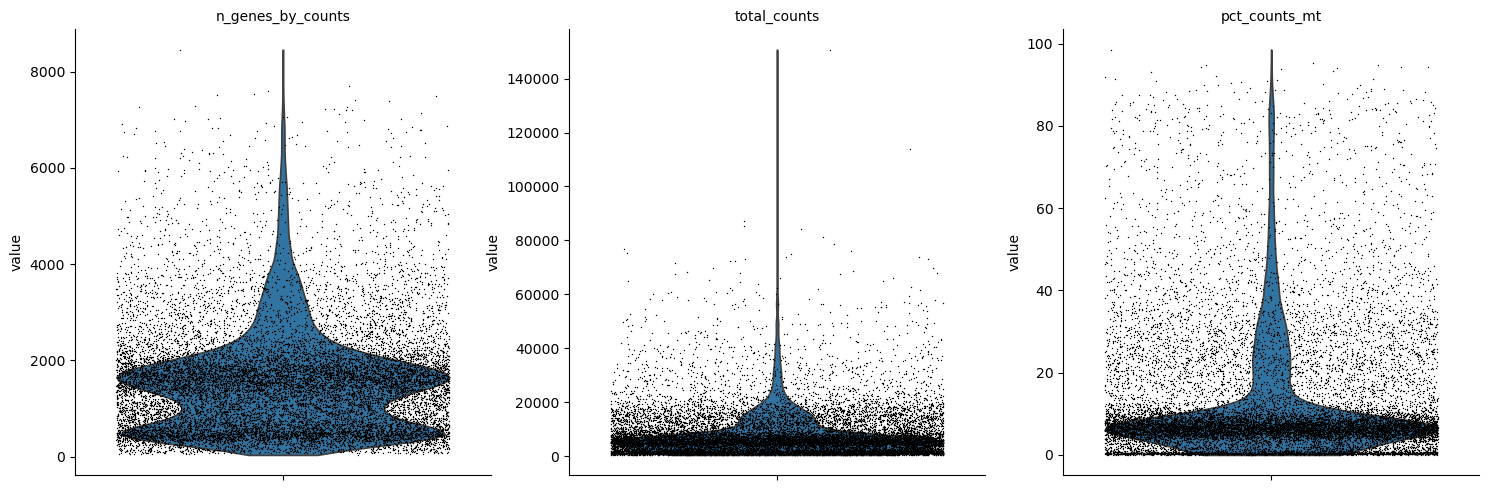

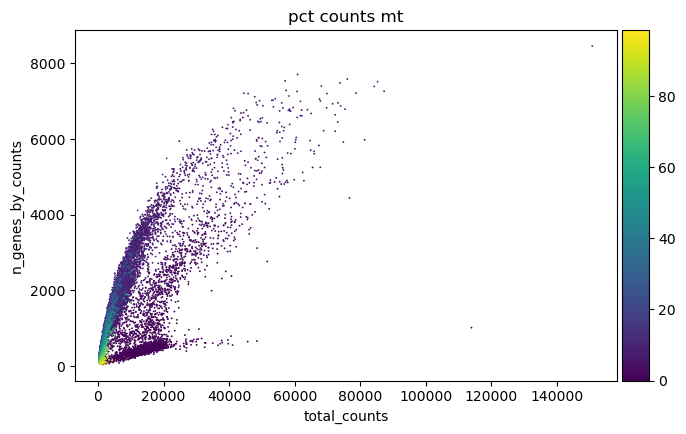

AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [7]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True) 
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
) 
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt") 
adata

In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3) 
sc.pp.scrublet(adata, batch_key="sample") 
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

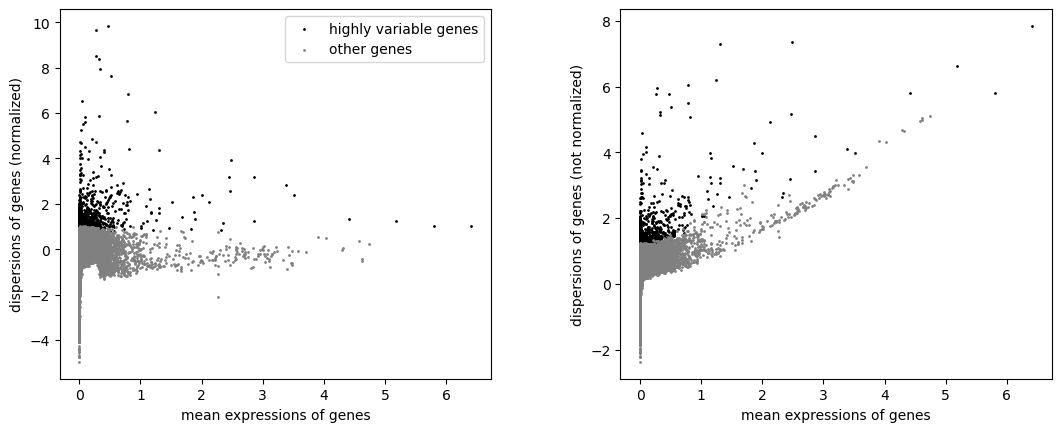

In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)

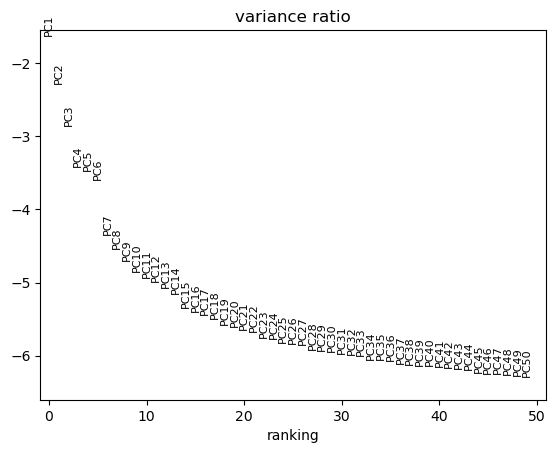

In [10]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

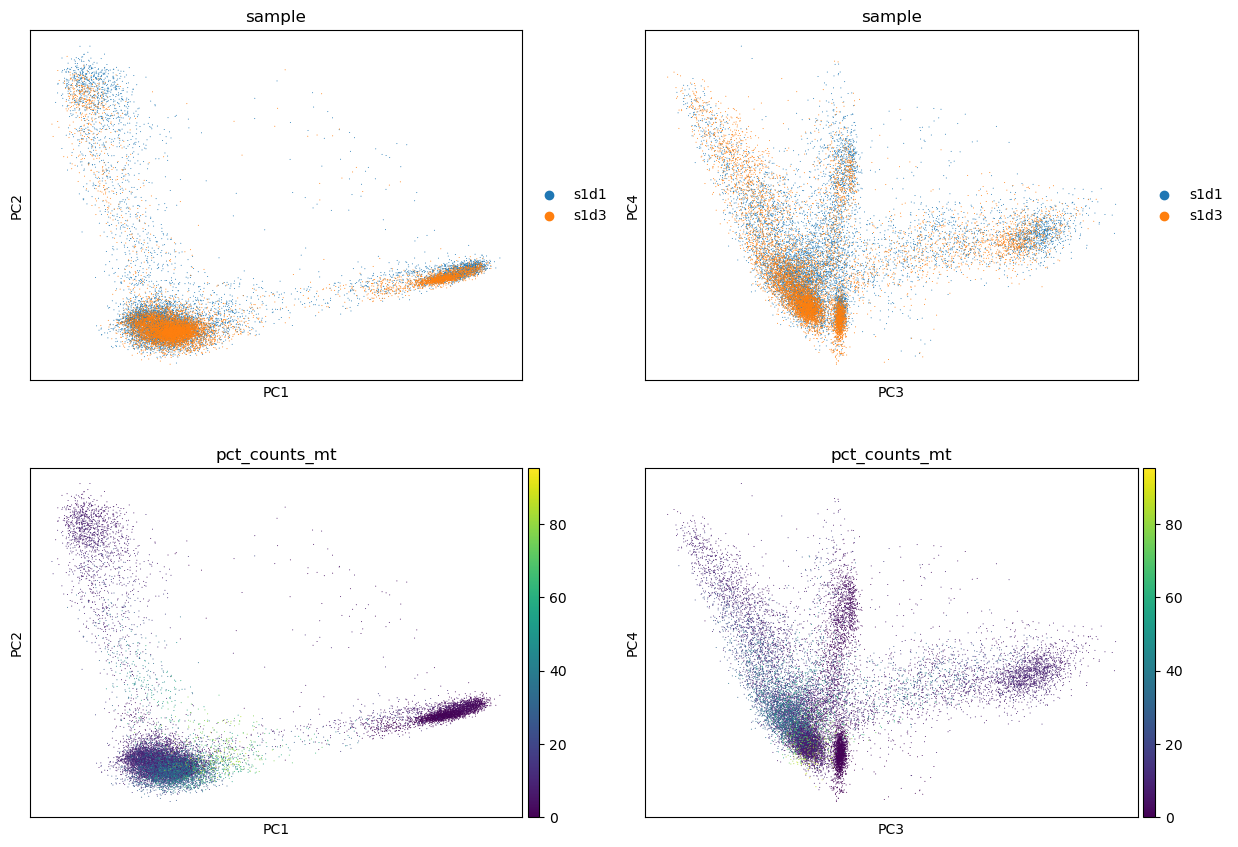

In [11]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [13]:
print(adata)

AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'sample_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'


In [14]:

print(adata.X.shape)

(17041, 23427)


In [15]:
print(adata.obs.head())

                   sample  n_genes_by_counts  log1p_n_genes_by_counts  \
AAACCCAAGGATGGCT-1   s1d1               2103                 7.651596   
AAACCCAAGGCCTAGA-1   s1d1               3916                 8.273081   
AAACCCAAGTGAGTGC-1   s1d1                683                 6.527958   
AAACCCACAAGAGGCT-1   s1d1               4330                 8.373554   
AAACCCACATCGTGGC-1   s1d1                325                 5.786897   

                    total_counts  log1p_total_counts  \
AAACCCAAGGATGGCT-1        8663.0            9.066932   
AAACCCAAGGCCTAGA-1       12853.0            9.461411   
AAACCCAAGTGAGTGC-1        1631.0            7.397562   
AAACCCACAAGAGGCT-1       17345.0            9.761117   
AAACCCACATCGTGGC-1         555.0            6.320768   

                    pct_counts_in_top_50_genes  pct_counts_in_top_100_genes  \
AAACCCAAGGATGGCT-1                   42.721921                    59.667552   
AAACCCAAGGCCTAGA-1                   35.843772                    

In [16]:
print(adata.var.head())

               mt   ribo     hb  n_cells_by_counts  mean_counts  \
AL627309.1  False  False  False                 40     0.002336   
AL627309.3  False  False  False                  3     0.000175   
AL627309.5  False  False  False                155     0.009460   
AL627309.4  False  False  False                  7     0.000409   
AP006222.2  False  False  False                  3     0.000234   

            log1p_mean_counts  pct_dropout_by_counts  total_counts  \
AL627309.1           0.002333              99.766423          40.0   
AL627309.3           0.000175              99.982482           3.0   
AL627309.5           0.009415              99.094891         162.0   
AL627309.4           0.000409              99.959124           7.0   
AP006222.2           0.000234              99.982482           4.0   

            log1p_total_counts  n_cells  highly_variable     means  \
AL627309.1            3.713572       40            False  0.002273   
AL627309.3            1.386294      

In [17]:


print(adata.layers.keys())

KeysView(Layers with keys: counts)
